# 01. Создание датасета

Цель ноутбука — получить воспроизводимый датасет для прогнозирования средней суточной температуры воздуха в Волгограде. Мы загрузим исторические данные Meteostat, агрегируем почасовые наблюдения до уровня дней, сформируем признаки и сохраним итоговый CSV-файл для дальнейшего моделирования.

## Почему в качестве сырья выбраны hourly-данные

Целевая переменная исследования — средняя суточная температура воздуха. Её можно взять из суточных данных напрямую, но для учебного проекта полезнее начать именно с почасовых наблюдений:

- из hourly-данных можно получить среднюю суточную температуру как агрегат;
- одновременно можно вычислить более информативные суточные признаки: минимальную и максимальную температуру, диапазон температур, среднее давление, среднюю влажность, среднюю точку росы и другие агрегаты;
- суточные данные Meteostat используются как запасной источник для аккуратного заполнения отдельных пропусков.

Такой подход делает датасет богаче и лучше иллюстрирует этап инженерии признаков.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.constants import DEFAULT_START_DATE, FIGURES_DIR, FIXED_DATA_END_DATE
from src.utils import (
    aggregate_hourly_to_daily,
    apply_missing_value_strategy,
    combine_hourly_and_daily_features,
    describe_missing_values,
    ensure_project_directories,
    fetch_meteostat_data,
    load_raw_snapshots,
    prepare_daily_fallback,
    save_processed_dataset,
    save_raw_snapshots,
    subset_raw_snapshots,
)

ensure_project_directories()

## Шаг 1. Настройка периода и логики выбора источника

Ниже задаётся временной интервал исследования. Конечная дата фиксируется в конфигурации проекта: это делает результаты воспроизводимыми и не зависит от дня запуска ноутбука.

Логика выбора источника такая:

- сначала рассматриваются ближайшие станции Meteostat рядом с Волгоградом;
- затем выбирается ближайшая станция с наиболее подходящим покрытием hourly и daily данных;
- если станция не подходит или не отвечает, используется fallback по координатам Волгограда;
- если сетевая загрузка недоступна, используются ранее сохранённые raw-файлы из `data/raw`.


In [2]:
START_DATE = DEFAULT_START_DATE
END_DATE = FIXED_DATA_END_DATE

print(f"Период загрузки: с {START_DATE} по {END_DATE}")
print("Конечная дата зафиксирована в коде проекта, чтобы результаты не зависели от дня запуска.")
print("Сначала пробуем ближайшие станции Meteostat, затем при необходимости переходим к загрузке по координатам.")

Период загрузки: с 2010-01-01 по 2025-12-31
Конечная дата зафиксирована в коде проекта, чтобы результаты не зависели от дня запуска.
Сначала пробуем ближайшие станции Meteostat, затем при необходимости переходим к загрузке по координатам.


In [3]:
try:
    selection_info, station_candidates, daily_raw, hourly_raw = fetch_meteostat_data(
        start=START_DATE,
        end=END_DATE,
    )
    hourly_raw_path, daily_raw_path = save_raw_snapshots(hourly=hourly_raw, daily=daily_raw)
except Exception as exc:
    daily_raw, hourly_raw = load_raw_snapshots()
    daily_raw, hourly_raw = subset_raw_snapshots(
        daily_frame=daily_raw,
        hourly_frame=hourly_raw,
        start=START_DATE,
        end=END_DATE,
    )
    hourly_raw_path = PROJECT_ROOT / "data" / "raw" / "volgograd_hourly_raw.csv"
    daily_raw_path = PROJECT_ROOT / "data" / "raw" / "volgograd_daily_raw.csv"
    station_candidates = pd.DataFrame()
    selection_info = {
        "source_type": "local_raw_csv",
        "station_id": "LOCAL_CACHE",
        "station_name": "Волгоград",
        "country": "RU",
        "region": "Волгоградская область",
        "distance_km": 0.0,
        "note": f"Использованы локальные raw-данные из data/raw, потому что загрузка из Meteostat завершилась ошибкой: {exc}",
    }

candidate_columns = [
    column
    for column in [
        "station_id",
        "name",
        "country",
        "region",
        "distance_km",
        "latitude",
        "longitude",
        "hourly_start",
        "hourly_end",
        "daily_start",
        "daily_end",
        "coverage_score",
    ]
    if column in station_candidates.columns
]

candidate_view = station_candidates[candidate_columns].copy() if candidate_columns else pd.DataFrame()
for column in ["hourly_start", "hourly_end", "daily_start", "daily_end"]:
    if column in candidate_view.columns:
        candidate_view[column] = pd.to_datetime(candidate_view[column]).dt.date

if "distance_km" in candidate_view.columns:
    candidate_view["distance_km"] = candidate_view["distance_km"].round(2)

display(Markdown("### Ближайшие станции-кандидаты"))
if candidate_view.empty:
    print("Список кандидатов не показан, так как использован локальный CSV fallback.")
else:
    display(candidate_view.head(5))

display(Markdown("### Выбранный источник данных"))
display(pd.DataFrame([selection_info]))

print(f"Сырые hourly-данные сохранены в: {hourly_raw_path}")
print(f"Сырые daily-данные сохранены в: {daily_raw_path}")
print(f"Размер hourly-таблицы: {hourly_raw.shape}")
print(f"Размер daily-таблицы: {daily_raw.shape}")

### Ближайшие станции-кандидаты

,station_id,name,country,region,distance_km,latitude,longitude
0,34560,Volgograd,RU,VG,13.63,48.7833,44.3667


### Выбранный источник данных

,source_type,station_id,station_name,country,region,distance_km,latitude,longitude,elevation
0,station,34560,Volgograd,RU,VG,13.63,48.7833,44.3667,145.0


Сырые hourly-данные сохранены в: /home/nochami/projects/0kursovaya/data/raw/volgograd_hourly_raw.csv
Сырые daily-данные сохранены в: /home/nochami/projects/0kursovaya/data/raw/volgograd_daily_raw.csv
Размер hourly-таблицы: (139432, 11)
Размер daily-таблицы: (5843, 11)


## Шаг 2. Агрегация hourly-данных до уровня суток

На этом шаге почасовые наблюдения сворачиваются до уровня дней. Именно здесь формируются основные метеорологические признаки, которые потом войдут в итоговый датасет.

Суточные данные используются как fallback: если по какому-то дню в hourly-источнике не хватает наблюдений, необходимые величины берутся из `Daily`.

In [4]:
hourly_daily = aggregate_hourly_to_daily(hourly_raw)
daily_fallback = prepare_daily_fallback(daily_raw)
combined_dataset = combine_hourly_and_daily_features(
    hourly_daily=hourly_daily,
    daily_fallback=daily_fallback,
)

print("Первые строки агрегированных hourly-признаков:")
display(hourly_daily.head())

print("Первые строки объединённого суточного датасета до финальной обработки:")
display(combined_dataset.head())

missing_before = describe_missing_values(combined_dataset)
display(Markdown("### Пропуски до финальной очистки"))
if missing_before.empty:
    print("На этом этапе явных пропусков не обнаружено.")
else:
    display(missing_before.round(3))

Первые строки агрегированных hourly-признаков:


,date,target_tavg,tmin,tmax,prcp_sum,pres_mean,wspd_mean,wpgt_max,rhum_mean,tsun_sum,snow,temp_observations,temp_range
0,2010-01-01,1.508333,0.6,2.0,0.0,1003.3,21.6,<NA>,97.708333,0,<NA>,24,1.4
1,2010-01-02,2.765217,0.0,5.6,0.0,997.614286,24.886957,<NA>,99.956522,0,<NA>,23,5.6
2,2010-01-03,0.2,-9.0,6.2,0.0,997.414286,25.669565,<NA>,95.173913,0,<NA>,23,15.2
3,2010-01-04,-11.2375,-13.0,-8.4,0.0,1014.45,21.75,<NA>,84.958333,0,<NA>,24,4.6
4,2010-01-05,-11.025,-14.3,-7.0,0.0,1028.814286,7.65,<NA>,79.666667,0,<NA>,24,7.3


Первые строки объединённого суточного датасета до финальной обработки:


,date,target_tavg,tmin,tmax,prcp_sum,pres_mean,wspd_mean,wpgt_max,rhum_mean,tsun_sum,snow,temp_observations,temp_range
0,2010-01-01,1.508333,0.6,2.0,0.0,1003.3,21.6,<NA>,97.708333,0,16,24,1.4
1,2010-01-02,2.765217,0.0,5.6,0.0,997.614286,24.886957,<NA>,99.956522,0,12,23,5.6
2,2010-01-03,0.2,-9.0,6.2,0.0,997.414286,25.669565,<NA>,95.173913,0,5,23,15.2
3,2010-01-04,-11.2375,-13.0,-8.4,0.0,1014.45,21.75,<NA>,84.958333,0,2,24,4.6
4,2010-01-05,-11.025,-14.3,-7.0,0.0,1028.814286,7.65,<NA>,79.666667,0,2,24,7.3


### Пропуски до финальной очистки

,missing_count,missing_share
wpgt_max,5725,0.980
snow,5345,0.915
tmin,5,0.001
temp_range,5,0.001
target_tavg,1,0.000
tmax,1,0.000


## Шаг 3. Обработка пропусков и формирование окончательных признаков

Используется консервативная стратегия обработки пропусков:

- для целевой переменной `target_tavg` приоритет отдан hourly-агрегации, а при недостатке почасовых наблюдений используется суточный fallback;
- метеорологические признаки заполняются только односторонним `forward fill` на коротком интервале, то есть без подглядывания в будущие даты;
- признаки `rhum_mean` и `dwpt_mean` считаются опциональными: если Meteostat не даёт их для выбранного источника данных, ноутбук не падает, а продолжает работу без этих столбцов;
- строки без достаточной исторической информации для лагов и скользящих статистик удаляются в самом конце.

Такой подход делает датасет устойчивым и при этом не нарушает причинно-следственную логику временного ряда.

In [5]:
dataset = apply_missing_value_strategy(combined_dataset)
output_path = save_processed_dataset(dataset)

optional_features = ["snow", "wpgt_max", "rhum_mean", "dwpt_mean", "tsun_sum"]
available_optional = [column for column in optional_features if column in dataset.columns]
missing_optional = [column for column in optional_features if column not in dataset.columns]

print(f"Число строк до финальной очистки: {len(combined_dataset):,}")
print(f"Число строк после финальной очистки: {len(dataset):,}")
print(f"Итоговый файл датасета: {output_path}")
print(f"Доступные опциональные признаки: {available_optional if available_optional else 'нет'}")
print(f"Недоступные опциональные признаки: {missing_optional if missing_optional else 'нет'}")

display(dataset.head())
display(Markdown("### Итоговые столбцы датасета"))
display(pd.Series(dataset.columns, name="column_name"))

Число строк до финальной очистки: 5,844
Число строк после финальной очистки: 5,813
Итоговый файл датасета: /home/nochami/projects/0kursovaya/data/processed/volgograd_daily_temperature_dataset.csv
Доступные опциональные признаки: ['snow', 'rhum_mean', 'tsun_sum']
Недоступные опциональные признаки: ['wpgt_max', 'dwpt_mean']


,date,target_tavg,tmin,tmax,temp_range,prcp_sum,snow,pres_mean,wspd_mean,rhum_mean,tsun_sum,month,dayofyear,dayofweek,season,season_code,doy_sin,doy_cos,lag_1,lag_2,lag_3,lag_7,lag_14,lag_30,rolling_mean_3,rolling_mean_7,rolling_mean_14,rolling_std_7,rolling_std_14
0,2010-01-31,-2.745833,-7.0,0.0,7.0,0.0,23,1020.55,20.1,99.166667,0,1,31,6,зима,0,0.508356,0.861147,-6.208333,-16.117391,-17.145833,-17.633333,-17.116667,1.508333,-13.157186,-14.840036,-16.461982,3.896986,3.212234
1,2010-02-01,-5.595652,-7.8,-3.9,3.9,0.0,23,1018.825,23.55,98.565217,0,2,32,0,зима,0,0.523094,0.852275,-2.745833,-6.208333,-16.117391,-15.466667,-17.204167,2.765217,-8.357186,-12.713251,-15.435494,5.743456,4.860298
2,2010-02-02,-3.943478,-6.1,-2.0,4.1,0.0,23,1018.771429,18.782609,99.826087,0,2,33,1,зима,0,0.537677,0.843151,-5.595652,-2.745833,-6.208333,-15.386957,-16.958333,0.2,-4.849940,-11.303106,-14.606315,6.152006,5.485373
3,2010-02-03,-8.109091,-13.6,-6.0,7.6,0.0,23,1019.942857,36.654545,96.227273,0,2,34,2,зима,0,0.552101,0.833777,-3.943478,-5.595652,-2.745833,-15.921739,-17.995833,-11.2375,-4.094988,-9.668323,-13.676682,6.401325,6.122005
4,2010-02-04,-14.621739,-17.0,-11.8,5.2,0.0,23,1030.071429,47.895652,84.782609,0,2,35,3,зима,0,0.566362,0.824157,-8.109091,-3.943478,-5.595652,-17.145833,-19.3375,-11.025,-5.882740,-8.552230,-12.970486,5.780255,6.155593


### Итоговые столбцы датасета

0                date
1         target_tavg
2                tmin
3                tmax
4          temp_range
5            prcp_sum
6                snow
7           pres_mean
8           wspd_mean
9           rhum_mean
10           tsun_sum
11              month
12          dayofyear
13          dayofweek
14             season
15        season_code
16            doy_sin
17            doy_cos
18              lag_1
19              lag_2
20              lag_3
21              lag_7
22             lag_14
23             lag_30
24     rolling_mean_3
25     rolling_mean_7
26    rolling_mean_14
27      rolling_std_7
28     rolling_std_14
Name: column_name, dtype: str

## Шаг 4. Первичный анализ данных

Для проверки качества подготовленного датасета ниже выводятся:

- период наблюдений;
- число записей;
- информация о пропусках после подготовки;
- описательные статистики;
- график временного ряда;
- сезонность по месяцам.

In [6]:
period_start = dataset["date"].min().date()
period_end = dataset["date"].max().date()

print(f"Период наблюдений после очистки: {period_start} - {period_end}")
print(f"Количество записей: {len(dataset):,}")
print(f"Количество столбцов: {dataset.shape[1]}")

missing_after = describe_missing_values(dataset)
display(Markdown("### Пропуски после подготовки"))
if missing_after.empty:
    print("После подготовки в итоговом датасете пропусков не осталось.")
else:
    display(missing_after.round(3))

display(Markdown("### Описательные статистики по числовым признакам"))
numeric_dataset = dataset.select_dtypes(include=["number"])
display(numeric_dataset.describe().transpose().round(3))

Период наблюдений после очистки: 2010-01-31 - 2025-12-31
Количество записей: 5,813
Количество столбцов: 29


### Пропуски после подготовки

После подготовки в итоговом датасете пропусков не осталось.


### Описательные статистики по числовым признакам

,count,mean,std,min,25%,50%,75%,max
target_tavg,5813.0,9.717398,12.120539,-27.108696,0.004167,9.925,20.191667,34.129167
tmin,5813.0,4.635077,10.834554,-30.0,-3.0,5.0,14.0,27.0
tmax,5813.0,14.244177,13.471839,-25.9,2.0,15.0,26.0,41.0
temp_range,5813.0,9.610735,4.291645,0.4,6.0,10.0,13.0,24.0
prcp_sum,5813.0,0.249854,1.556257,0.0,0.0,0.0,0.0,46.3
snow,5813.0,1.330466,6.191376,0.0,0.0,0.0,0.0,61.0
pres_mean,5813.0,1017.223623,8.479878,987.779167,1011.408333,1016.2375,1022.129167,1054.4875
wspd_mean,5813.0,18.509535,6.886202,0.9,13.5,17.55,22.65,53.25
rhum_mean,5813.0,67.030516,21.501147,15.333333,48.666667,69.958333,85.958333,100.0
tsun_sum,5813.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


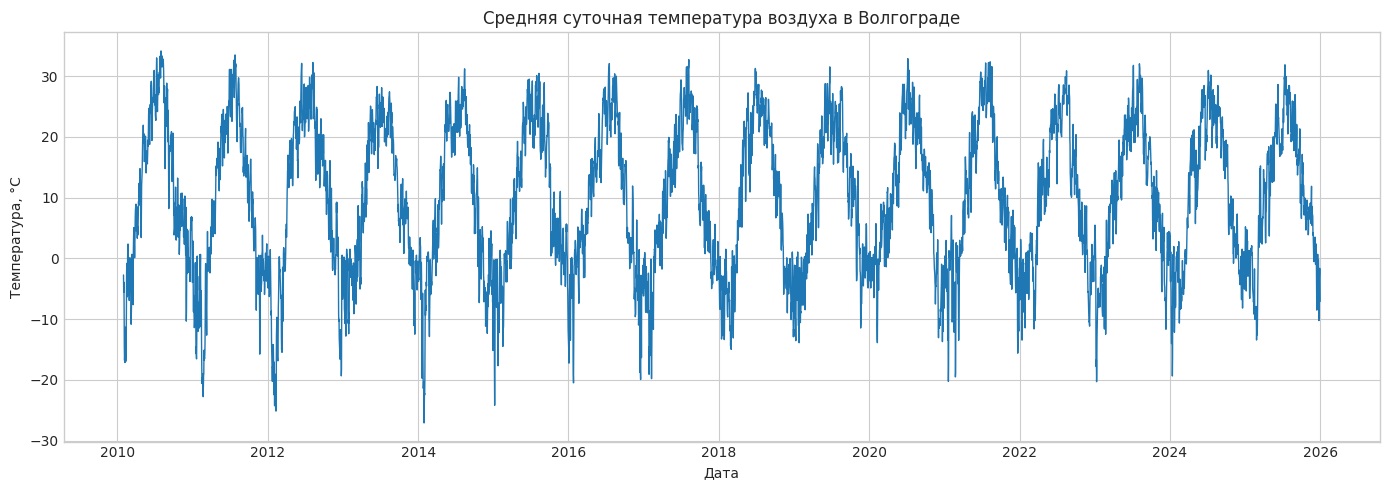

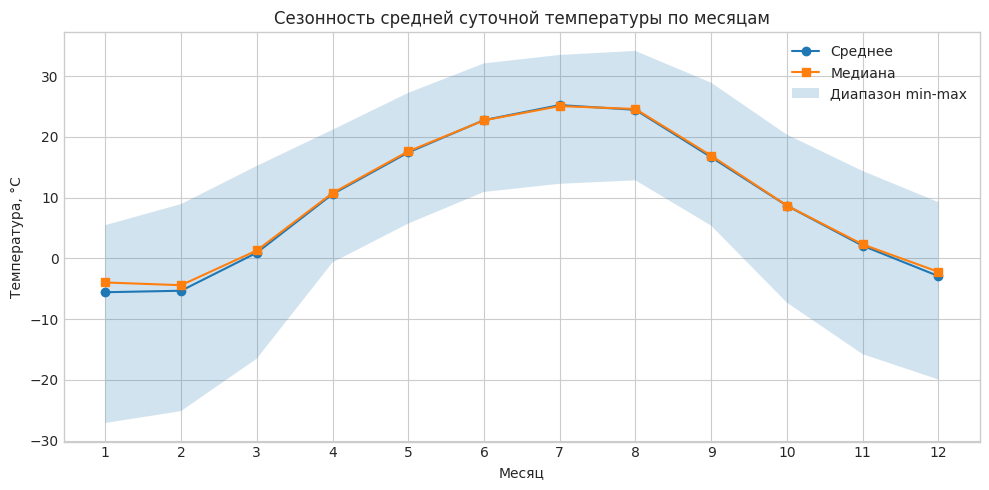

График временного ряда сохранён в: /home/nochami/projects/0kursovaya/outputs/figures/01_temperature_time_series.png
График сезонности по месяцам сохранён в: /home/nochami/projects/0kursovaya/outputs/figures/01_monthly_seasonality.png


In [7]:
time_series_path = FIGURES_DIR / "01_temperature_time_series.png"
seasonality_path = FIGURES_DIR / "01_monthly_seasonality.png"

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dataset["date"], dataset["target_tavg"], color="#1f77b4", linewidth=1.0)
ax.set_title("Средняя суточная температура воздуха в Волгограде")
ax.set_xlabel("Дата")
ax.set_ylabel("Температура, °C")
fig.tight_layout()
fig.savefig(time_series_path, dpi=200, bbox_inches="tight")
plt.show()

monthly_profile = dataset.groupby("month")["target_tavg"].agg(["mean", "median", "min", "max"]).reset_index()
months = monthly_profile["month"].to_numpy(dtype=float)
mean_values = monthly_profile["mean"].to_numpy(dtype=float)
median_values = monthly_profile["median"].to_numpy(dtype=float)
min_values = monthly_profile["min"].to_numpy(dtype=float)
max_values = monthly_profile["max"].to_numpy(dtype=float)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(months, mean_values, marker="o", label="Среднее")
ax.plot(months, median_values, marker="s", label="Медиана")
ax.fill_between(
    months,
    min_values,
    max_values,
    alpha=0.2,
    label="Диапазон min-max",
)
ax.set_title("Сезонность средней суточной температуры по месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Температура, °C")
ax.set_xticks(range(1, 13))
ax.legend()
fig.tight_layout()
fig.savefig(seasonality_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"График временного ряда сохранён в: {time_series_path}")
print(f"График сезонности по месяцам сохранён в: {seasonality_path}")

In [8]:
feature_list = ", ".join(dataset.columns)

summary_text = f"""
## Итог

Подготовлен датасет на уровне дней для задачи прогнозирования средней суточной температуры воздуха в Волгограде.

- Создан файл `{output_path.relative_to(PROJECT_ROOT)}`.
- В датасете `{len(dataset)}` наблюдений за период с `{period_start}` по `{period_end}`.
- Получены метеорологические, календарные, лаговые и скользящие признаки.
- Такой датасет подходит для обучения статистических моделей, классических ML-подходов и нейросетей.

Итоговые столбцы: `{feature_list}`.
"""

display(Markdown(summary_text))


## Итог

Подготовлен датасет на уровне дней для задачи прогнозирования средней суточной температуры воздуха в Волгограде.

- Создан файл `data/processed/volgograd_daily_temperature_dataset.csv`.
- В датасете `5813` наблюдений за период с `2010-01-31` по `2025-12-31`.
- Получены метеорологические, календарные, лаговые и скользящие признаки.
- Такой датасет подходит для обучения статистических моделей, классических ML-подходов и нейросетей.

Итоговые столбцы: `date, target_tavg, tmin, tmax, temp_range, prcp_sum, snow, pres_mean, wspd_mean, rhum_mean, tsun_sum, month, dayofyear, dayofweek, season, season_code, doy_sin, doy_cos, lag_1, lag_2, lag_3, lag_7, lag_14, lag_30, rolling_mean_3, rolling_mean_7, rolling_mean_14, rolling_std_7, rolling_std_14`.
